# Enterprise Model Development Notebook
This notebook covers the full end-to-end machine learning pipeline for the highly detailed Hospital Management System, mapping complex patient datasets into actionable AI pipelines.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
Loading the synthetic raw data generated for the HMS.

In [2]:
patients_df = pd.read_csv('../data/raw/patients.csv')
appointments_df = pd.read_csv('../data/raw/appointments.csv')
admissions_df = pd.read_csv('../data/raw/admissions.csv')
resources_df = pd.read_csv('../data/raw/hospital_resources.csv')

## 2. Data Inspection
Inspecting shape, info, head, null values, duplicates, and general descriptions.

In [3]:
# Checking shapes
print("Patients Shape:", patients_df.shape)
print("Appointments Shape:", appointments_df.shape)
print("Admissions Shape:", admissions_df.shape)

Patients Shape: (1500, 7)
Appointments Shape: (3000, 7)
Admissions Shape: (1500, 6)


In [4]:
# Duplicates and Null values
print("Appointments Duplicates:", appointments_df.duplicated().sum())
print("Admissions Duplicates:", admissions_df.duplicated().sum())

Appointments Duplicates: 0
Admissions Duplicates: 0


## 3. Data Merging & EDA
Merging operational data with patient history for deep feature creation.

In [5]:
# Merge Appointments with Patients
ns_full = pd.merge(appointments_df, patients_df, on='patient_id', how='left')

# Merge Admissions with Patients
occ_full = pd.merge(admissions_df, patients_df, on='patient_id', how='left')

print(ns_full.head(3))

  appointment_id patient_id  department consultation_type  wait_time_hours  \
0         A00001     P00738     general           Initial               79   
1         A00002     P00758  cardiology         Follow-up              128   
2         A00003     P00567  pediatrics         Follow-up              413   

                  date  no_show  age gender blood_group chronic_condition  \
0  2025-11-01 22:00:00        1   54   male         ab-               NaN   
1  2025-10-29 10:00:00        0   63   male         ab-               NaN   
2  2025-08-04 09:00:00        1    9   male          b-               NaN   

   distance_to_hospital_km  historical_no_show_rate  
0                     95.1                     0.09  
1                     74.8                     0.15  
2                     47.4                     0.39  


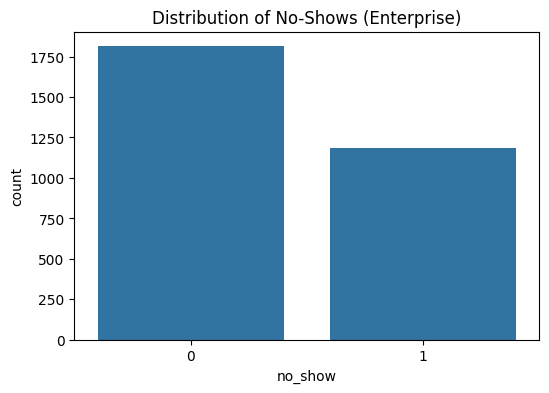

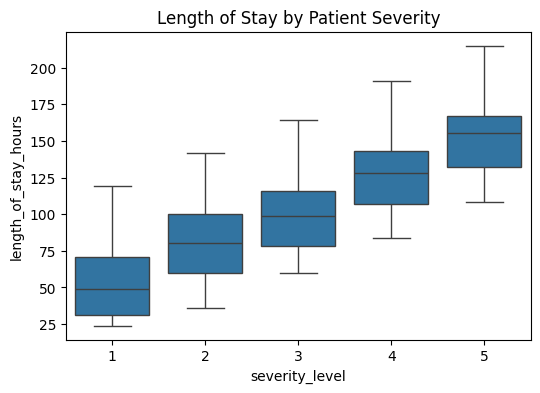

In [6]:
# Target imbalance check for No-Shows
plt.figure(figsize=(6,4))
sns.countplot(data=ns_full, x='no_show')
plt.title('Distribution of No-Shows (Enterprise)')
plt.show()

# Boxplot for outliers in length of stay vs Severity
plt.figure(figsize=(6,4))
sns.boxplot(data=occ_full, x='severity_level', y='length_of_stay_hours')
plt.title('Length of Stay by Patient Severity')
plt.show()

## 4. Feature Engineering
Encoding categorical features for modeling.

In [7]:
# Encoding
le_dept = LabelEncoder()
ns_full['department_code'] = le_dept.fit_transform(ns_full['department'])

le_cond = LabelEncoder()
ns_full['chronic_code'] = le_cond.fit_transform(ns_full['chronic_condition'])

le_cons = LabelEncoder()
ns_full['consultation_code'] = le_cons.fit_transform(ns_full['consultation_type'])

le_ward = LabelEncoder()
occ_full['ward_code'] = le_ward.fit_transform(occ_full['ward'])

occ_full['chronic_code'] = le_cond.transform(occ_full['chronic_condition'])

le_adm = LabelEncoder()
occ_full['admission_code'] = le_adm.fit_transform(occ_full['admission_type'])

print("Categorical Encoding Completed.")

Categorical Encoding Completed.


## 5. Modeling: Patient No-Show Prediction
Using a classification model based on patient history, demographics, and wait time.

In [8]:
features_ns = ['department_code', 'chronic_code', 'consultation_code', 'wait_time_hours', 'distance_to_hospital_km', 'historical_no_show_rate', 'age']
x_ns = ns_full[features_ns]
y_ns = ns_full['no_show']

# Dataset split
x_train_ns, x_test_ns, y_train_ns, y_test_ns = train_test_split(x_ns, y_ns, test_size=0.2, random_state=42)

# Train
rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42)
rf_classifier.fit(x_train_ns, y_train_ns)

# Evaluate
preds_ns = rf_classifier.predict(x_test_ns)
print(f"Accuracy: {accuracy_score(y_test_ns, preds_ns):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ns, preds_ns))

Accuracy: 0.5967

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.77      0.69       358
           1       0.50      0.34      0.41       242

    accuracy                           0.60       600
   macro avg       0.57      0.56      0.55       600
weighted avg       0.58      0.60      0.58       600



### Feature Importance (No-Show)

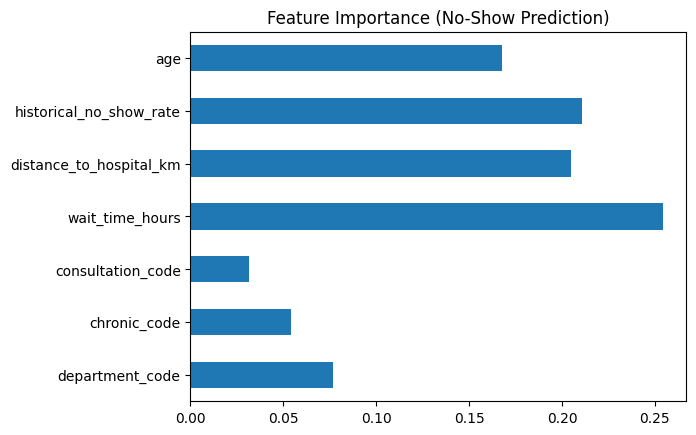

In [9]:
pd.Series(rf_classifier.feature_importances_, index=x_ns.columns).plot(kind='barh')
plt.title('Feature Importance (No-Show Prediction)')
plt.show()

## 6. Modeling: Bed Occupancy Prediction
Using a regression model leveraging severity and patient age.

In [10]:
features_occ = ['ward_code', 'chronic_code', 'admission_code', 'severity_level', 'age']
x_occ = occ_full[features_occ]
y_occ = occ_full['length_of_stay_hours']

# Split
x_train_occ, x_test_occ, y_train_occ, y_test_occ = train_test_split(x_occ, y_occ, test_size=0.2, random_state=42)

# Train
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=42)
rf_regressor.fit(x_train_occ, y_train_occ)

# Evaluate
preds_occ = rf_regressor.predict(x_test_occ)
print(f"MSE: {mean_squared_error(y_test_occ, preds_occ):.4f}")
print(f"R2 Score: {r2_score(y_test_occ, preds_occ):.4f}")

MSE: 333.7425
R2 Score: 0.8291


## 7. Final Model Serialization
Saving the best models and encoders for production inference.

In [11]:
os.makedirs('../models', exist_ok=True)
joblib.dump(le_dept, '../models/le_dept.pkl')
joblib.dump(le_cond, '../models/le_cond.pkl')
joblib.dump(le_cons, '../models/le_cons.pkl')
joblib.dump(rf_classifier, '../models/no_show_rf.pkl')

joblib.dump(le_ward, '../models/le_ward.pkl')
joblib.dump(le_adm, '../models/le_adm.pkl')
joblib.dump(rf_regressor, '../models/occupancy_rf.pkl')

print("Models and Encoders successfully serialized to models/ folder.")

Models and Encoders successfully serialized to models/ folder.
